In [26]:
# 1. ?????


import os
import copy
import numpy as np
import pandas as pd
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

In [27]:
import torch
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 4060


In [28]:
# 2. 4~8월 cargo CSV 로딩

file_paths = [
    r"C:\Users\HP\Desktop\prE\04cargo.csv",
    r"C:\Users\HP\Desktop\prE\05cargo.csv",
    r"C:\Users\HP\Desktop\prE\06cargo.csv",
    r"C:\Users\HP\Desktop\prE\07cargo.csv",
    r"C:\Users\HP\Desktop\prE\08cargo.csv",
]

df_list = []

for path in file_paths:
    temp = pd.read_csv(path)
    temp["source_file"] = os.path.basename(path)
    df_list.append(temp)

df_raw = pd.concat(df_list, ignore_index=True)

print(df_raw.shape)
print(df_raw.columns)
df_raw.head()

(4500839, 20)
Index(['MMSI', 'Date', 'Lat', 'Long', 'SOG', 'COG', 'Heading', 'Name', 'Type',
       'IMO', 'Call', 'DimA', 'DimB', 'DimC', 'DimD', 'Draft', 'Tons',
       'Length', 'Breadth', 'source_file'],
      dtype='str')


,MMSI,Date,Lat,Long,SOG,COG,Heading,Name,Type,IMO,Call,DimA,DimB,DimC,DimD,Draft,Tons,Length,Breadth,source_file
0,215331000,2024-04-01 00:02:56,35.067482,128.808068,0.0,285.7,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv
1,215331000,2024-04-01 00:05:56,35.067487,128.808107,0.0,233.2,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv
2,215331000,2024-04-01 00:08:56,35.067478,128.808130,0.0,236.5,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv
3,215331000,2024-04-01 00:11:56,35.067490,128.808120,0.0,242.4,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv
4,215331000,2024-04-01 00:14:56,35.067518,128.808348,0.0,238.9,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv


In [29]:
# 3. 컬럼 정리 및 기본 전처리

df = df_raw[["MMSI", "Date", "Lat", "Long", "SOG", "COG", "Heading", "source_file"]].copy()

df = df.rename(columns={
    "Date": "timestamp",
    "Lat": "lat",
    "Long": "lon",
    "SOG": "sog",
    "COG": "cog",
    "Heading": "heading"
})

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

for col in ["lat", "lon", "sog", "cog", "heading"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["MMSI", "timestamp", "lat", "lon", "sog", "cog", "heading"])

df = df[
    (df["lat"].between(-90, 90)) &
    (df["lon"].between(-180, 180)) &
    (df["sog"] >= 0) &
    (df["cog"].between(0, 360)) &
    (df["heading"].between(0, 360))
].copy()

df = df.sort_values(["MMSI", "timestamp"]).reset_index(drop=True)

df["month"] = df["timestamp"].dt.month

print(df.shape)
print(df["month"].value_counts().sort_index())
df.head()

(4417967, 9)
month
4    826933
5    900471
6    907346
7    912136
8    871081
Name: count, dtype: int64


,MMSI,timestamp,lat,lon,sog,cog,heading,source_file,month
0,209079000,2024-08-05 03:42:22,34.960100,128.823167,9.9,339.7,338,08cargo.csv,8
1,209079000,2024-08-05 03:42:32,34.960518,128.822972,9.8,339.7,338,08cargo.csv,8
2,209079000,2024-08-05 03:42:42,34.960935,128.822775,9.6,339.1,338,08cargo.csv,8
3,209079000,2024-08-05 03:42:52,34.961335,128.822592,9.4,338.6,338,08cargo.csv,8
4,209079000,2024-08-05 03:43:02,34.961732,128.822387,9.3,338.0,338,08cargo.csv,8


In [30]:
# 4. 이동 선박 / 정지 선박 기준

MOVING_THRESHOLD = 0.5

moving_df = df[df["sog"] > MOVING_THRESHOLD].copy()
stationary_df = df[df["sog"] <= MOVING_THRESHOLD].copy()

print("전체 데이터:", len(df))
print("이동 선박 데이터:", len(moving_df))
print("정지/저속 선박 데이터:", len(stationary_df))

전체 데이터: 4417967
이동 선박 데이터: 2614784
정지/저속 선박 데이터: 1803183


In [31]:
# 5. Grid 설정
# Interaction Graph 학습용: 0.5 NM
# 최종 혼잡도 시각화용: 1.0 NM

TRAIN_GRID_NM = 0.1
VIS_GRID_NM = 0.1

BASE_LAT_FOR_LON_SCALE = 35.0

TRAIN_LAT_GRID_SIZE = (TRAIN_GRID_NM * 1.852) / 111
TRAIN_LON_GRID_SIZE = (TRAIN_GRID_NM * 1.852) / (
    111 * np.cos(np.radians(BASE_LAT_FOR_LON_SCALE))
)

VIS_LAT_GRID_SIZE = (VIS_GRID_NM * 1.852) / 111
VIS_LON_GRID_SIZE = (VIS_GRID_NM * 1.852) / (
    111 * np.cos(np.radians(BASE_LAT_FOR_LON_SCALE))
)

print("TRAIN_LAT_GRID_SIZE:", TRAIN_LAT_GRID_SIZE)
print("TRAIN_LON_GRID_SIZE:", TRAIN_LON_GRID_SIZE)
print("VIS_LAT_GRID_SIZE:", VIS_LAT_GRID_SIZE)
print("VIS_LON_GRID_SIZE:", VIS_LON_GRID_SIZE)

TRAIN_LAT_GRID_SIZE: 0.0016684684684684687
TRAIN_LON_GRID_SIZE: 0.0020368239084560514
VIS_LAT_GRID_SIZE: 0.0016684684684684687
VIS_LON_GRID_SIZE: 0.0020368239084560514


In [32]:
# 6. AIS ??? 5? ?? resampling ??
# ????? ???? ???. ?? ??? ?? 5? bin? ???.
# COG/Heading? ?? ??? ????.

RESAMPLE_INTERVAL = "5min"
MAX_REASONABLE_SPEED_KNOTS = 40
MAX_REASONABLE_STEP_KM = 6


def circular_mean_deg(series):
    values = series.dropna().values

    if len(values) == 0:
        return np.nan

    radians = np.radians(values)
    sin_mean = np.mean(np.sin(radians))
    cos_mean = np.mean(np.cos(radians))

    angle = np.degrees(np.arctan2(sin_mean, cos_mean))
    return angle + 360 if angle < 0 else angle


def haversine_km_np(lat1, lon1, lat2, lon2):
    R = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c


def resample_ais_5min(df, progress_step=10):
    result = []
    grouped = list(df.groupby("MMSI"))
    total = len(grouped)
    next_progress = progress_step

    print(f"Resampling start: {total} vessels")

    for idx, (mmsi, group) in enumerate(grouped, start=1):
        group = group.sort_values("timestamp").set_index("timestamp")

        resampled = group[["lat", "lon", "sog"]].resample(RESAMPLE_INTERVAL).mean()
        resampled["cog"] = group["cog"].resample(RESAMPLE_INTERVAL).apply(circular_mean_deg)
        resampled["heading"] = group["heading"].resample(RESAMPLE_INTERVAL).apply(circular_mean_deg)

        resampled = resampled.dropna()
        resampled["MMSI"] = mmsi
        result.append(resampled.reset_index())

        progress = idx / total * 100 if total else 100
        if progress >= next_progress or idx == total:
            print(f"Resampling progress: {progress:.1f}% ({idx}/{total} vessels)")
            next_progress += progress_step

    if len(result) == 0:
        return pd.DataFrame(columns=["timestamp", "lat", "lon", "sog", "cog", "heading", "MMSI"])

    return pd.concat(result, ignore_index=True)


def remove_unrealistic_jumps(df, max_speed_knots=MAX_REASONABLE_SPEED_KNOTS, max_step_km=MAX_REASONABLE_STEP_KM):
    cleaned = []
    removed_count = 0

    for mmsi, group in df.groupby("MMSI"):
        group = group.sort_values("timestamp").copy()

        prev_lat = group["lat"].shift(1)
        prev_lon = group["lon"].shift(1)
        prev_time = group["timestamp"].shift(1)

        dt_hours = (group["timestamp"] - prev_time).dt.total_seconds() / 3600
        dist_km = haversine_km_np(prev_lat, prev_lon, group["lat"], group["lon"])
        speed_knots = (dist_km / 1.852) / dt_hours

        valid = (
            prev_time.isna()
            | (
                (dt_hours > 0)
                & (speed_knots <= max_speed_knots)
                & (dist_km <= max_step_km)
            )
        )

        removed_count += int((~valid).sum())
        cleaned.append(group.loc[valid])

    result = pd.concat(cleaned, ignore_index=True) if cleaned else df.iloc[0:0].copy()
    print(f"Removed unrealistic jump rows: {removed_count}")
    return result


def add_direction_features(df):
    result = df.copy()

    result["cog_sin"] = np.sin(np.radians(result["cog"]))
    result["cog_cos"] = np.cos(np.radians(result["cog"]))
    result["heading_sin"] = np.sin(np.radians(result["heading"]))
    result["heading_cos"] = np.cos(np.radians(result["heading"]))

    return result

In [33]:
# 7. ? ?? Train / Validation / Test ?? ? resampling
# ?? ??? ?? ???? ? ???? ?? ??? ?? ? ???? split ? resampling??.
# ????? ???? ??, ??? AIS jump? ??? ? ?? sin/cos feature? ????.

train_month_raw = moving_df[moving_df["month"].isin([4, 5, 6])].copy()
val_month_raw = moving_df[moving_df["month"].isin([7])].copy()
test_month_raw = moving_df[moving_df["month"].isin([8])].copy()

train_raw = resample_ais_5min(train_month_raw, progress_step=5)
val_raw = resample_ais_5min(val_month_raw, progress_step=5)
test_raw = resample_ais_5min(test_month_raw, progress_step=5)

train_raw = add_direction_features(remove_unrealistic_jumps(train_raw))
val_raw = add_direction_features(remove_unrealistic_jumps(val_raw))
test_raw = add_direction_features(remove_unrealistic_jumps(test_raw))

for split_df in [train_raw, val_raw, test_raw]:
    split_df["month"] = split_df["timestamp"].dt.month

moving_resampled = pd.concat([train_raw, val_raw, test_raw], ignore_index=True)
moving_resampled = moving_resampled.sort_values(["MMSI", "timestamp"]).reset_index(drop=True)

print("train_raw:", train_raw.shape)
print("val_raw:", val_raw.shape)
print("test_raw:", test_raw.shape)
print("all moving_resampled:", moving_resampled.shape)

Resampling start: 1083 vessels
Resampling progress: 5.1% (55/1083 vessels)
Resampling progress: 10.1% (109/1083 vessels)
Resampling progress: 15.1% (163/1083 vessels)
Resampling progress: 20.0% (217/1083 vessels)
Resampling progress: 25.0% (271/1083 vessels)
Resampling progress: 30.0% (325/1083 vessels)
Resampling progress: 35.1% (380/1083 vessels)
Resampling progress: 40.1% (434/1083 vessels)
Resampling progress: 45.1% (488/1083 vessels)
Resampling progress: 50.0% (542/1083 vessels)
Resampling progress: 55.0% (596/1083 vessels)
Resampling progress: 60.0% (650/1083 vessels)
Resampling progress: 65.0% (704/1083 vessels)
Resampling progress: 70.1% (759/1083 vessels)
Resampling progress: 75.1% (813/1083 vessels)
Resampling progress: 80.1% (867/1083 vessels)
Resampling progress: 85.0% (921/1083 vessels)
Resampling progress: 90.0% (975/1083 vessels)
Resampling progress: 95.0% (1029/1083 vessels)
Resampling progress: 100.0% (1083/1083 vessels)
Resampling start: 547 vessels
Resampling progres

In [34]:
# 8. ???
# ?? feature? lat/lon/sog? ?? sin/cos? ????.
# target? ?? ?? ??? ??? ?? ?? ?? ?? 5? delta_lat/delta_lon??.

feature_cols = [
    "lat", "lon", "sog",
    "cog_sin", "cog_cos",
    "heading_sin", "heading_cos"
]
target_cols = ["delta_lat", "delta_lon"]

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()


def build_delta_target_frame(raw_df, interval_minutes=5):
    rows = []
    expected_delta = pd.Timedelta(minutes=interval_minutes)

    for _, group in raw_df.groupby("MMSI"):
        group = group.sort_values("timestamp").reset_index(drop=True)

        next_lat = group["lat"].shift(-1)
        next_lon = group["lon"].shift(-1)
        next_time = group["timestamp"].shift(-1)

        is_continuous = (next_time - group["timestamp"]) == expected_delta
        delta_df = pd.DataFrame({
            "delta_lat": next_lat - group["lat"],
            "delta_lon": next_lon - group["lon"]
        })

        rows.append(delta_df.loc[is_continuous].dropna())

    if len(rows) == 0:
        return pd.DataFrame(columns=target_cols)

    return pd.concat(rows, ignore_index=True)


train_delta_targets = build_delta_target_frame(train_raw)

x_scaler.fit(train_raw[feature_cols])
y_scaler.fit(train_delta_targets[target_cols])


def apply_scaling(raw_df):
    norm_df = raw_df.copy()
    norm_df[feature_cols] = x_scaler.transform(raw_df[feature_cols])
    return norm_df


train_norm = apply_scaling(train_raw)
val_norm = apply_scaling(val_raw)
test_norm = apply_scaling(test_raw)
all_norm = apply_scaling(moving_resampled)

print("delta target rows for scaler:", len(train_delta_targets))
train_norm.head()

delta target rows for scaler: 46964


,timestamp,lat,lon,sog,cog,heading,MMSI,cog_sin,cog_cos,heading_sin,heading_cos,month
0,2024-04-15 10:35:00,0.002318,0.898242,0.095379,338.500000,340.0,209423000,0.316749,0.965209,0.32899,0.969846,4
1,2024-04-15 10:40:00,0.058490,0.844810,0.093379,339.103334,340.0,209423000,0.321658,0.967113,0.32899,0.969846,4
2,2024-04-15 10:45:00,0.160297,0.750063,0.081613,339.240000,340.0,209423000,0.322773,0.967537,0.32899,0.969846,4
3,2024-04-15 10:50:00,0.252004,0.664034,0.076696,339.216667,340.0,209423000,0.322582,0.967464,0.32899,0.969846,4
4,2024-04-15 10:55:00,0.346525,0.578389,0.086988,339.506666,340.0,209423000,0.324951,0.968356,0.32899,0.969846,4


In [35]:
# 9. Interaction transition statistics ??
# train_raw?? grid ? ?? ??? ????.
# ?? sequence? interaction adjacency matrix? 10??? ? ??? ??? ???.


def latlon_to_grid(lat, lon, lat_min, lon_min, lat_grid_size, lon_grid_size):
    row = int((lat - lat_min) / lat_grid_size)
    col = int((lon - lon_min) / lon_grid_size)
    return row, col


def build_interaction_counts(df):
    transition_counts = defaultdict(int)

    lat_min = df["lat"].min()
    lon_min = df["lon"].min()

    for mmsi, group in df.groupby("MMSI"):
        group = group.sort_values("timestamp")
        coords = group[["lat", "lon"]].values

        for i in range(len(coords) - 1):
            g1 = latlon_to_grid(
                coords[i][0], coords[i][1],
                lat_min, lon_min,
                TRAIN_LAT_GRID_SIZE, TRAIN_LON_GRID_SIZE
            )
            g2 = latlon_to_grid(
                coords[i + 1][0], coords[i + 1][1],
                lat_min, lon_min,
                TRAIN_LAT_GRID_SIZE, TRAIN_LON_GRID_SIZE
            )
            transition_counts[(g1, g2)] += 1

    return transition_counts, lat_min, lon_min


transition_counts, train_lat_min, train_lon_min = build_interaction_counts(train_raw)

print("interaction transition count:", len(transition_counts))
print("train_lat_min:", train_lat_min)
print("train_lon_min:", train_lon_min)

interaction transition count: 13134
train_lat_min: 34.96
train_lon_min: 128.770005


In [36]:
# 10. Sequence? Multi-Graph ?? ??
# Distance graph? sequence? ??? ?? ????,
# Interaction graph? 9??? ?? train ?? transition statistics? ????.

DISTANCE_GRAPH_SIGMA_KM = 0.5


def create_distance_graph(raw_seq, sigma_km=DISTANCE_GRAPH_SIGMA_KM):
    coords = raw_seq[:, :2]

    lat_km = coords[:, 0] * 111.0
    lon_km = coords[:, 1] * 111.0 * np.cos(np.radians(BASE_LAT_FOR_LON_SCALE))
    xy = np.stack([lat_km, lon_km], axis=1)

    diff = xy[:, None, :] - xy[None, :, :]
    dist_km = np.sqrt(np.sum(diff ** 2, axis=-1))

    A = np.exp(-dist_km / sigma_km)
    return A.astype(np.float32)


def create_interaction_graph(raw_seq):
    N = len(raw_seq)
    A = np.zeros((N, N), dtype=np.float32)

    nodes = [
        latlon_to_grid(
            row[0], row[1],
            train_lat_min, train_lon_min,
            TRAIN_LAT_GRID_SIZE, TRAIN_LON_GRID_SIZE
        )
        for row in raw_seq
    ]

    for i in range(N):
        for j in range(N):
            A[i, j] = transition_counts.get((nodes[i], nodes[j]), 0)

    if A.max() > 0:
        A = A / (A.max() + 1e-6)

    return A.astype(np.float32)


def create_multi_graph(raw_seq):
    A_distance = create_distance_graph(raw_seq)
    A_interaction = create_interaction_graph(raw_seq)
    return np.stack([A_distance, A_interaction], axis=0).astype(np.float32)

In [37]:
# 11. 과거 10개 시점으로 다음 5분 이동량 예측 sequence 생성
# history 내부 간격은 최대 10분까지 허용하되,
# 마지막 입력 시점 -> target 시점은 정확히 5분인 경우만 사용한다.

def create_next_step_sequences_with_graph(raw_df, norm_df, seq_len=10, stride=1, max_sequences=None):
    sequences = []
    max_gap = np.timedelta64(10, "m")
    target_gap = np.timedelta64(5, "m")

    for mmsi in raw_df["MMSI"].unique():
        raw_group = raw_df[raw_df["MMSI"] == mmsi].sort_values("timestamp").reset_index(drop=True)
        norm_group = norm_df[norm_df["MMSI"] == mmsi].sort_values("timestamp").reset_index(drop=True)

        if len(raw_group) <= seq_len:
            continue

        raw_data = raw_group[feature_cols].values.astype(np.float32)
        norm_data = norm_group[feature_cols].values.astype(np.float32)
        timestamps = raw_group["timestamp"].values.astype("datetime64[ns]")

        for i in range(0, len(raw_group) - seq_len, stride):
            time_window = timestamps[i:i + seq_len + 1]
            time_diffs = np.diff(time_window).astype("timedelta64[m]")

            history_diffs = time_diffs[:-1]
            target_diff = time_diffs[-1]

            if not np.all((history_diffs > np.timedelta64(0, "m")) & (history_diffs <= max_gap)):
                continue

            if target_diff != target_gap:
                continue

            raw_seq = raw_data[i:i + seq_len]
            norm_seq = norm_data[i:i + seq_len]

            current_pos = raw_data[i + seq_len - 1][:2]
            next_pos = raw_data[i + seq_len][:2]
            raw_delta = next_pos - current_pos

            target = y_scaler.transform(
                pd.DataFrame([raw_delta], columns=target_cols)
            )[0].astype(np.float32)

            graph = create_multi_graph(raw_seq)
            sequences.append((norm_seq, graph, target))

            if max_sequences is not None and len(sequences) >= max_sequences:
                return sequences

    return sequences


SEQ_LEN = 10
TRAIN_STRIDE = 1
VAL_STRIDE = 1
TEST_STRIDE = 1

MAX_TRAIN_SEQUENCES = None
MAX_VAL_SEQUENCES = None
MAX_TEST_SEQUENCES = None

train_sequences = create_next_step_sequences_with_graph(
    train_raw,
    train_norm,
    seq_len=SEQ_LEN,
    stride=TRAIN_STRIDE,
    max_sequences=MAX_TRAIN_SEQUENCES
)

val_sequences = create_next_step_sequences_with_graph(
    val_raw,
    val_norm,
    seq_len=SEQ_LEN,
    stride=VAL_STRIDE,
    max_sequences=MAX_VAL_SEQUENCES
)

test_sequences = create_next_step_sequences_with_graph(
    test_raw,
    test_norm,
    seq_len=SEQ_LEN,
    stride=TEST_STRIDE,
    max_sequences=MAX_TEST_SEQUENCES
)

print("train_sequences:", len(train_sequences))
print("val_sequences:", len(val_sequences))
print("test_sequences:", len(test_sequences))

if len(train_sequences) > 0:
    print("sample norm_seq:", train_sequences[0][0].shape)
    print("sample graph:", train_sequences[0][1].shape)
    print("sample target:", train_sequences[0][2].shape)
else:
    print("train_sequences가 비어 있습니다.")

train_sequences: 10792
val_sequences: 4080
test_sequences: 3628
sample norm_seq: (10, 7)
sample graph: (2, 10, 10)
sample target: (2,)


In [38]:
# 12. Dataset / DataLoader
# graph는 이미 pre-compute 되어 있음

class AISDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        norm_seq, graph, target = self.sequences[idx]

        return (
            torch.tensor(norm_seq, dtype=torch.float32),
            torch.tensor(graph, dtype=torch.float32),
            torch.tensor(target, dtype=torch.float32)
        )


BATCH_SIZE = 32

train_dataset = AISDataset(train_sequences)
val_dataset = AISDataset(val_sequences)
test_dataset = AISDataset(test_sequences)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

for X, graphs, y in train_loader:
    print("X:", X.shape)
    print("graphs:", graphs.shape)
    print("y:", y.shape)
    break

X: torch.Size([32, 10, 7])
graphs: torch.Size([32, 2, 10, 10])
y: torch.Size([32, 2])


In [39]:
# 13. STMGCN ?? ??
# Spatial-Temporal Multi-Graph Convolutional Network

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, X, A):
        B, T, _ = X.shape

        I = torch.eye(T, device=X.device, dtype=X.dtype).unsqueeze(0).expand(B, T, T)
        A_hat = A.to(dtype=X.dtype) + I

        degree = torch.sum(A_hat, dim=-1).clamp_min(1e-6)
        degree_inv_sqrt = torch.pow(degree, -0.5)
        A_norm = degree_inv_sqrt.unsqueeze(-1) * A_hat * degree_inv_sqrt.unsqueeze(-2)

        H = A_norm @ self.linear(X)
        H = F.relu(H)
        H = self.dropout(H)

        return self.norm(H)


class MultiGraphAttentionFusion(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.score_layer = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, H_list):
        scores = []

        for H in H_list:
            graph_score = self.score_layer(H).mean(dim=1)
            scores.append(graph_score)

        scores = torch.cat(scores, dim=1)
        weights = F.softmax(scores, dim=1)

        fused = torch.zeros_like(H_list[0])
        for i, H in enumerate(H_list):
            w = weights[:, i].view(-1, 1, 1)
            fused = fused + w * H

        return fused, weights


class TemporalConvBlock(nn.Module):
    def __init__(self, hidden_dim, kernel_size=3, dropout=0.1):
        super().__init__()
        padding = kernel_size // 2

        self.filter_conv = nn.Conv1d(hidden_dim, hidden_dim, kernel_size, padding=padding)
        self.gate_conv = nn.Conv1d(hidden_dim, hidden_dim, kernel_size, padding=padding)
        self.proj = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=1)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x):
        residual = x

        x = x.transpose(1, 2)
        z = torch.tanh(self.filter_conv(x))
        g = torch.sigmoid(self.gate_conv(x))
        x = self.proj(z * g)
        x = self.dropout(x)
        x = x.transpose(1, 2)

        return self.norm(x + residual)


class STMGCN(nn.Module):
    def __init__(
        self,
        input_dim=5,
        hidden_dim=64,
        num_graphs=2,
        output_dim=2,
        num_temporal_blocks=2,
        dropout=0.1
    ):
        super().__init__()

        self.num_graphs = num_graphs

        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim)
        )

        self.gcn_layers = nn.ModuleList([
            GCNLayer(hidden_dim, hidden_dim, dropout=dropout)
            for _ in range(num_graphs)
        ])

        self.graph_fusion = MultiGraphAttentionFusion(hidden_dim)

        self.temporal_blocks = nn.ModuleList([
            TemporalConvBlock(hidden_dim, dropout=dropout)
            for _ in range(num_temporal_blocks)
        ])

        self.output_layer = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim)
        )

        self.last_graph_weights = None

    def forward(self, X, graphs):
        H0 = self.input_projection(X)

        H_list = []
        for i in range(self.num_graphs):
            A = graphs[:, i, :, :]
            H = self.gcn_layers[i](H0, A)
            H_list.append(H)

        H, graph_weights = self.graph_fusion(H_list)
        self.last_graph_weights = graph_weights.detach()

        for block in self.temporal_blocks:
            H = block(H)

        last_hidden = H[:, -1, :]
        return self.output_layer(last_hidden)

In [40]:
# 14. ?? ??

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = STMGCN(
    input_dim=len(feature_cols),
    hidden_dim=64,
    num_graphs=2,
    output_dim=2,
    num_temporal_blocks=2,
    dropout=0.1
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.MSELoss()

device: cuda


In [41]:
# 15. ?? ?? + Validation ?? + Early Stopping


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for X, graphs, y in loader:
        X = X.to(device)
        graphs = graphs.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        pred = model(X, graphs)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate_loss(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X, graphs, y in loader:
            X = X.to(device)
            graphs = graphs.to(device)
            y = y.to(device)

            pred = model(X, graphs)
            loss = criterion(pred, y)
            total_loss += loss.item()

    return total_loss / len(loader)


EPOCHS = 2000
PATIENCE = 150

best_val_loss = float("inf")
patience_counter = 0
best_model_state = None

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss = evaluate_loss(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch + 1}/{EPOCHS}] Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early stopping")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("Best Val Loss:", best_val_loss)

Epoch [1/2000] Train Loss: 0.015172 | Val Loss: 0.002289
Epoch [2/2000] Train Loss: 0.006542 | Val Loss: 0.001910
Epoch [3/2000] Train Loss: 0.005029 | Val Loss: 0.001400
Epoch [4/2000] Train Loss: 0.004016 | Val Loss: 0.000934
Epoch [5/2000] Train Loss: 0.003199 | Val Loss: 0.000893
Epoch [6/2000] Train Loss: 0.002806 | Val Loss: 0.000946
Epoch [7/2000] Train Loss: 0.002297 | Val Loss: 0.000801
Epoch [8/2000] Train Loss: 0.001927 | Val Loss: 0.000770
Epoch [9/2000] Train Loss: 0.001607 | Val Loss: 0.000801
Epoch [10/2000] Train Loss: 0.001331 | Val Loss: 0.000511
Epoch [11/2000] Train Loss: 0.001109 | Val Loss: 0.000504
Epoch [12/2000] Train Loss: 0.000988 | Val Loss: 0.000438
Epoch [13/2000] Train Loss: 0.000877 | Val Loss: 0.000498
Epoch [14/2000] Train Loss: 0.000757 | Val Loss: 0.000440
Epoch [15/2000] Train Loss: 0.000702 | Val Loss: 0.000486
Epoch [16/2000] Train Loss: 0.000681 | Val Loss: 0.000475
Epoch [17/2000] Train Loss: 0.000650 | Val Loss: 0.000542
Epoch [18/2000] Train L

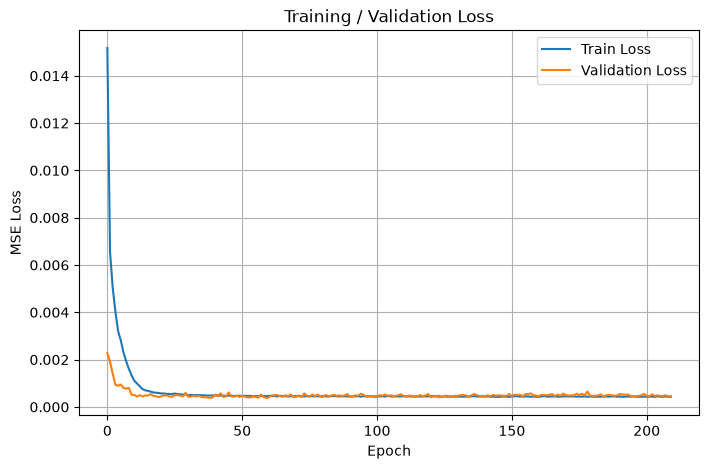

In [42]:
# 16. 학습 곡선 확인

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
# 17. Test set ?? 5? ??? ?? ??

model.eval()

with torch.no_grad():
    for X, graphs, y in test_loader:
        X = X.to(device)
        graphs = graphs.to(device)
        y = y.to(device)

        pred = model(X, graphs)

        pred_delta = y_scaler.inverse_transform(pred.cpu().numpy())
        true_delta = y_scaler.inverse_transform(y.cpu().numpy())

        print("?? delta_lat/delta_lon:")
        print(pred_delta[:5])

        print("?? delta_lat/delta_lon:")
        print(true_delta[:5])

        break

?? delta_lat/delta_lon:
[[ 0.00330531  0.00959843]
 [ 0.00180261  0.00733138]
 [ 0.00127413  0.00462728]
 [ 0.00072985  0.00099075]
 [-0.01185926  0.00439795]]
?? delta_lat/delta_lon:
[[ 0.00411606  0.0090332 ]
 [ 0.00266266  0.00724793]
 [ 0.00177002  0.00404358]
 [ 0.0009079   0.00086975]
 [-0.0104332   0.0039978 ]]


In [44]:
# 18. 선박 궤적 예측 함수
# 5분 one-step STMGCN을 반복 적용해 multi-horizon trajectory를 생성한다.
# AIS 수신 간격이 불규칙하므로 평가 허용 시간과 history 간격 조건을 완화한다.

FORECAST_MINUTES_LIST = [5, 10, 15, 30, 60]
MAX_FORECAST_MINUTES = max(FORECAST_MINUTES_LIST)

TOLERANCE_MINUTES = 3
MAX_HISTORY_GAP_MINUTES = 15
BASE_TIME_LOOKBACK_MINUTES = 60


def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c


def estimate_sog_cog_from_points(prev_lat, prev_lon, new_lat, new_lon, minutes=5):
    dist_km = haversine_km(prev_lat, prev_lon, new_lat, new_lon)
    sog_knots = (dist_km / 1.852) / (minutes / 60)

    dlon = np.radians(new_lon - prev_lon)
    lat1 = np.radians(prev_lat)
    lat2 = np.radians(new_lat)

    y = np.sin(dlon) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    cog = (np.degrees(np.arctan2(y, x)) + 360) % 360

    return sog_knots, cog


def predict_next_position(model, raw_seq, norm_seq):
    graph = create_multi_graph(raw_seq)

    X = torch.tensor(norm_seq, dtype=torch.float32).unsqueeze(0).to(device)
    graphs = torch.tensor(graph, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_delta_norm = model(X, graphs).cpu().numpy()

    pred_delta = y_scaler.inverse_transform(pred_delta_norm)[0]
    last_latlon = raw_seq[-1, :2]
    pred_latlon = last_latlon + pred_delta

    return pred_delta_norm[0], pred_delta, pred_latlon


def recursive_forecast_path(model, raw_seq, norm_seq, forecast_minutes=240):
    steps = int(forecast_minutes / 5)

    raw_seq = raw_seq.copy()
    norm_seq = norm_seq.copy()
    predicted_path = []

    for step in range(1, steps + 1):
        pred_delta_norm, pred_delta, pred_latlon = predict_next_position(model, raw_seq, norm_seq)

        prev_raw = raw_seq[-1].copy()
        new_raw = prev_raw.copy()

        new_raw[0] = pred_latlon[0]
        new_raw[1] = pred_latlon[1]

        est_sog, est_cog = estimate_sog_cog_from_points(
            prev_raw[0], prev_raw[1],
            pred_latlon[0], pred_latlon[1],
            minutes=5
        )

        new_raw[2] = est_sog
        new_raw[3] = np.sin(np.radians(est_cog))
        new_raw[4] = np.cos(np.radians(est_cog))
        new_raw[5] = np.sin(np.radians(est_cog))
        new_raw[6] = np.cos(np.radians(est_cog))

        new_norm = x_scaler.transform(pd.DataFrame([new_raw], columns=feature_cols))[0]

        raw_seq = np.vstack([raw_seq[1:], new_raw])
        norm_seq = np.vstack([norm_seq[1:], new_norm])

        predicted_path.append({
            "step": step,
            "forecast_minutes": step * 5,
            "lat": pred_latlon[0],
            "lon": pred_latlon[1]
        })

    return pd.DataFrame(predicted_path)


def generate_base_times(df, forecast_minutes, num_base_times=50):
    all_times = sorted(df["timestamp"].unique())
    max_allowed_time = df["timestamp"].max() - pd.Timedelta(minutes=forecast_minutes)
    candidate_times = [t for t in all_times if t <= max_allowed_time]

    if len(candidate_times) == 0:
        raise ValueError("미래 실제 위치를 확인할 수 있는 base_time이 없습니다.")

    if len(candidate_times) <= num_base_times:
        return candidate_times

    selected_idx = np.linspace(0, len(candidate_times) - 1, num_base_times).astype(int)
    return [candidate_times[i] for i in selected_idx]


def make_prediction_inputs_at_base_time(df_raw, df_norm, base_time, seq_len=10):
    pred_inputs = []

    lookback_start = base_time - pd.Timedelta(minutes=BASE_TIME_LOOKBACK_MINUTES)
    current_df = df_raw[
        (df_raw["timestamp"] >= lookback_start) &
        (df_raw["timestamp"] <= base_time)
    ].copy()

    if len(current_df) == 0:
        return pred_inputs

    latest_idx = current_df.groupby("MMSI")["timestamp"].idxmax()
    current_snapshot = current_df.loc[latest_idx].copy()
    moving_snapshot = current_snapshot[current_snapshot["sog"] > MOVING_THRESHOLD].copy()

    for _, row in moving_snapshot.iterrows():
        mmsi = row["MMSI"]
        current_time = row["timestamp"]

        hist_raw = df_raw[
            (df_raw["MMSI"] == mmsi) &
            (df_raw["timestamp"] <= current_time)
        ].sort_values("timestamp").tail(seq_len)

        hist_norm = df_norm[
            (df_norm["MMSI"] == mmsi) &
            (df_norm["timestamp"] <= current_time)
        ].sort_values("timestamp").tail(seq_len)

        if len(hist_raw) < seq_len or len(hist_norm) < seq_len:
            continue

        time_diffs = hist_raw["timestamp"].diff().dropna()

        if not (time_diffs <= pd.Timedelta(minutes=MAX_HISTORY_GAP_MINUTES)).all():
            continue

        pred_inputs.append({
            "MMSI": mmsi,
            "base_time": current_time,
            "start_lat": hist_raw.iloc[-1]["lat"],
            "start_lon": hist_raw.iloc[-1]["lon"],
            "raw_seq": hist_raw[feature_cols].values.astype(np.float32),
            "norm_seq": hist_norm[feature_cols].values.astype(np.float32)
        })

    return pred_inputs


def get_actual_position_near_time(df, mmsi, target_time, tolerance_minutes=10):
    tolerance = pd.Timedelta(minutes=tolerance_minutes)

    vessel_df = df[
        (df["MMSI"] == mmsi) &
        (df["timestamp"] >= target_time - tolerance) &
        (df["timestamp"] <= target_time + tolerance)
    ].copy()

    if len(vessel_df) == 0:
        return None

    vessel_df["time_diff"] = (vessel_df["timestamp"] - target_time).abs()
    row = vessel_df.sort_values("time_diff").iloc[0]

    return {
        "timestamp": row["timestamp"],
        "lat": row["lat"],
        "lon": row["lon"]
    }


def get_actual_path_for_horizons(df, mmsi, base_time, forecast_minutes_list):
    rows = []

    for minutes in forecast_minutes_list:
        actual = get_actual_position_near_time(
            df,
            mmsi,
            base_time + pd.Timedelta(minutes=minutes),
            tolerance_minutes=TOLERANCE_MINUTES
        )

        if actual is None:
            continue

        rows.append({
            "forecast_minutes": minutes,
            "timestamp": actual["timestamp"],
            "lat": actual["lat"],
            "lon": actual["lon"]
        })

    return pd.DataFrame(rows)

In [51]:
# 19. Multi-horizon 선박 궤적 예측 실행
# 평가 가능한 선박 수를 확보하기 위해 base_time 수를 늘린다.

NUM_BASE_TIMES = 200

base_times = generate_base_times(
    test_raw,
    forecast_minutes=MAX_FORECAST_MINUTES,
    num_base_times=NUM_BASE_TIMES
)

trajectory_records = []
trajectory_paths = []

model.eval()

for base_idx, base_time in enumerate(base_times):
    print(f"[{base_idx + 1}/{len(base_times)}] base_time: {base_time}")

    pred_inputs = make_prediction_inputs_at_base_time(
        test_raw,
        test_norm,
        base_time,
        seq_len=SEQ_LEN
    )

    if len(pred_inputs) == 0:
        print("예측 가능한 이동 선박 없음. skip")
        continue

    print("prediction input vessels:", len(pred_inputs))

    for item in pred_inputs:
        mmsi = item["MMSI"]
        vessel_base_time = item["base_time"]

        pred_path = recursive_forecast_path(
            model,
            item["raw_seq"],
            item["norm_seq"],
            forecast_minutes=MAX_FORECAST_MINUTES
        )

        actual_path = get_actual_path_for_horizons(
            test_raw,
            mmsi,
            vessel_base_time,
            FORECAST_MINUTES_LIST
        )

        if len(actual_path) == 0:
            continue

        pred_horizon = pred_path[
            pred_path["forecast_minutes"].isin(FORECAST_MINUTES_LIST)
        ].copy()

        merged = pred_horizon.merge(
            actual_path,
            on="forecast_minutes",
            suffixes=("_pred", "_actual")
        )

        if len(merged) == 0:
            continue

        for _, row in merged.iterrows():
            error_km = haversine_km(
                row["lat_actual"], row["lon_actual"],
                row["lat_pred"], row["lon_pred"]
            )

            trajectory_records.append({
                "base_time": vessel_base_time,
                "MMSI": mmsi,
                "forecast_minutes": row["forecast_minutes"],
                "pred_lat": row["lat_pred"],
                "pred_lon": row["lon_pred"],
                "actual_lat": row["lat_actual"],
                "actual_lon": row["lon_actual"],
                "error_km": error_km,
                "error_nm": error_km / 1.852
            })

        trajectory_paths.append({
            "base_time": vessel_base_time,
            "MMSI": mmsi,
            "start_lat": item["start_lat"],
            "start_lon": item["start_lon"],
            "pred_path": pred_horizon.reset_index(drop=True),
            "actual_path": actual_path.reset_index(drop=True)
        })

trajectory_results_df = pd.DataFrame(trajectory_records)

print("trajectory result rows:", len(trajectory_results_df))
print("trajectory paths:", len(trajectory_paths))

if len(trajectory_results_df) > 0:
    display(trajectory_results_df.head())
else:
    print("평가 가능한 trajectory 결과가 없습니다. TOLERANCE_MINUTES 또는 BASE_TIME_LOOKBACK_MINUTES를 더 늘려야 합니다.")

[1/200] base_time: 2024-08-01 00:00:00
예측 가능한 이동 선박 없음. skip
[2/200] base_time: 2024-08-01 04:35:00
prediction input vessels: 2
[3/200] base_time: 2024-08-01 07:55:00
prediction input vessels: 5
[4/200] base_time: 2024-08-01 13:55:00
prediction input vessels: 1
[5/200] base_time: 2024-08-01 17:00:00
prediction input vessels: 4
[6/200] base_time: 2024-08-01 20:10:00
prediction input vessels: 6
[7/200] base_time: 2024-08-02 00:00:00
prediction input vessels: 1
[8/200] base_time: 2024-08-02 03:15:00
prediction input vessels: 2
[9/200] base_time: 2024-08-02 06:20:00
prediction input vessels: 2
[10/200] base_time: 2024-08-02 10:55:00
예측 가능한 이동 선박 없음. skip
[11/200] base_time: 2024-08-02 14:00:00
prediction input vessels: 4
[12/200] base_time: 2024-08-02 17:05:00
prediction input vessels: 3
[13/200] base_time: 2024-08-02 21:30:00
prediction input vessels: 2
[14/200] base_time: 2024-08-03 00:50:00
prediction input vessels: 2
[15/200] base_time: 2024-08-03 04:45:00
prediction input vessels: 4
[

,base_time,MMSI,forecast_minutes,pred_lat,pred_lon,actual_lat,actual_lon,error_km,error_nm
0,2024-08-01 13:55:00,636017867,5,34.981056,128.799927,34.982096,128.799270,0.130128,0.070263
1,2024-08-01 13:55:00,636017867,10,34.967339,128.805130,34.970517,128.803670,0.377629,0.203904
2,2024-08-01 13:55:00,636017867,15,34.960068,128.808350,34.962402,128.807666,0.266950,0.144141
3,2024-08-01 17:00:00,440189000,5,35.075439,128.777618,35.074996,128.777367,0.054381,0.029363
4,2024-08-01 17:00:00,440189000,10,35.077278,128.775543,35.075977,128.775863,0.147625,0.079711


In [52]:
# 20. 예측 정확도 상위/하위 10개 선박 선택
# 기준: 5분 horizon에서 MMSI별 평균 error_km
# 단, 최소 평가 횟수(MIN_SHIP_COUNT) 이상인 선박만 후보로 사용한다.

TOP_N = 10
SELECTION_HORIZON = 5
PLOT_HORIZONS = [5, 10, 15, 30]
MIN_SHIP_COUNT = 2


def select_paths_by_ship_mean_error(
    trajectory_results_df,
    trajectory_paths,
    top=True,
    n=10,
    horizon=5,
    min_ship_count=2
):
    horizon_df = trajectory_results_df[
        trajectory_results_df["forecast_minutes"] == horizon
    ].copy()

    ship_score_df = (
        horizon_df
        .groupby("MMSI")
        .agg(
            mean_error_km=("error_km", "mean"),
            median_error_km=("error_km", "median"),
            min_error_km=("error_km", "min"),
            max_error_km=("error_km", "max"),
            count=("error_km", "count")
        )
        .reset_index()
    )

    ship_score_df = ship_score_df[
        ship_score_df["count"] >= min_ship_count
    ].copy()

    ship_score_df = ship_score_df.sort_values(
        "mean_error_km",
        ascending=top
    ).head(n).reset_index(drop=True)

    selected_paths = []

    for _, ship_row in ship_score_df.iterrows():
        mmsi = ship_row["MMSI"]

        ship_records = horizon_df[horizon_df["MMSI"] == mmsi]

        if top:
            selected_record = ship_records.sort_values("error_km", ascending=True).iloc[0]
        else:
            selected_record = ship_records.sort_values("error_km", ascending=False).iloc[0]

        matched = [
            item for item in trajectory_paths
            if item["MMSI"] == selected_record["MMSI"]
            and item["base_time"] == selected_record["base_time"]
        ]

        if len(matched) > 0:
            selected_paths.append(matched[0])

    return ship_score_df, selected_paths


def get_plot_nodes_5min(item, plot_horizons):
    pred_nodes = item["pred_path"][
        item["pred_path"]["forecast_minutes"].isin(plot_horizons)
    ].copy()

    actual_nodes = item["actual_path"][
        item["actual_path"]["forecast_minutes"].isin(plot_horizons)
    ].copy()

    merged = pred_nodes.merge(
        actual_nodes,
        on="forecast_minutes",
        suffixes=("_pred", "_actual")
    )

    merged = merged.sort_values("forecast_minutes").reset_index(drop=True)

    if len(merged) == 0:
        return None

    return merged


top10_df, top10_paths = select_paths_by_ship_mean_error(
    trajectory_results_df,
    trajectory_paths,
    top=True,
    n=TOP_N,
    horizon=SELECTION_HORIZON,
    min_ship_count=MIN_SHIP_COUNT
)

bottom10_df, bottom10_paths = select_paths_by_ship_mean_error(
    trajectory_results_df,
    trajectory_paths,
    top=False,
    n=TOP_N,
    horizon=SELECTION_HORIZON,
    min_ship_count=MIN_SHIP_COUNT
)

print(f"예측 정확도 상위 {TOP_N}개 선박")
print(f"선정 기준: {SELECTION_HORIZON}분 예측 평균 오차, count >= {MIN_SHIP_COUNT}")
display(top10_df)

print(f"예측 정확도 하위 {TOP_N}개 선박")
print(f"선정 기준: {SELECTION_HORIZON}분 예측 평균 오차, count >= {MIN_SHIP_COUNT}")
display(bottom10_df)

print("top selected paths:", len(top10_paths))
print("bottom selected paths:", len(bottom10_paths))

예측 정확도 상위 10개 선박
선정 기준: 5분 예측 평균 오차, count >= 2


,MMSI,mean_error_km,median_error_km,min_error_km,max_error_km,count
0,477220100,0.056979,0.056979,0.020929,0.093029,2
1,440189000,0.058438,0.058438,0.054381,0.062495,2
2,440009000,0.061265,0.061265,0.052995,0.069535,2
3,440273000,0.069319,0.069319,0.045917,0.092720,2
4,636022007,0.088635,0.088635,0.063825,0.113446,2
5,352002269,0.109444,0.109444,0.068633,0.150255,2
6,255806029,0.110698,0.110698,0.042027,0.179370,2
7,255806028,0.116827,0.116827,0.075826,0.157828,2
8,565887000,0.119128,0.119128,0.046253,0.192002,2
9,636020978,0.137501,0.096323,0.095489,0.220691,3


예측 정확도 하위 10개 선박
선정 기준: 5분 예측 평균 오차, count >= 2


,MMSI,mean_error_km,median_error_km,min_error_km,max_error_km,count
0,636020978,0.137501,0.096323,0.095489,0.220691,3
1,565887000,0.119128,0.119128,0.046253,0.192002,2
2,255806028,0.116827,0.116827,0.075826,0.157828,2
3,255806029,0.110698,0.110698,0.042027,0.179370,2
4,352002269,0.109444,0.109444,0.068633,0.150255,2
5,636022007,0.088635,0.088635,0.063825,0.113446,2
6,440273000,0.069319,0.069319,0.045917,0.092720,2
7,440009000,0.061265,0.061265,0.052995,0.069535,2
8,440189000,0.058438,0.058438,0.054381,0.062495,2
9,477220100,0.056979,0.056979,0.020929,0.093029,2


top selected paths: 10
bottom selected paths: 10


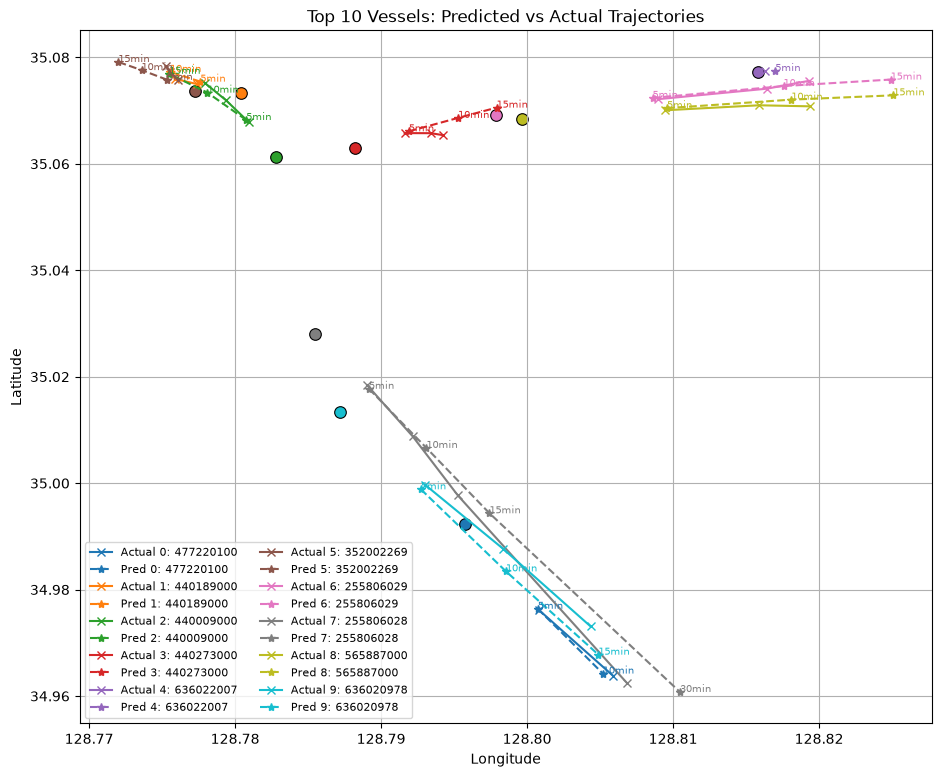

plotted vessels: 10


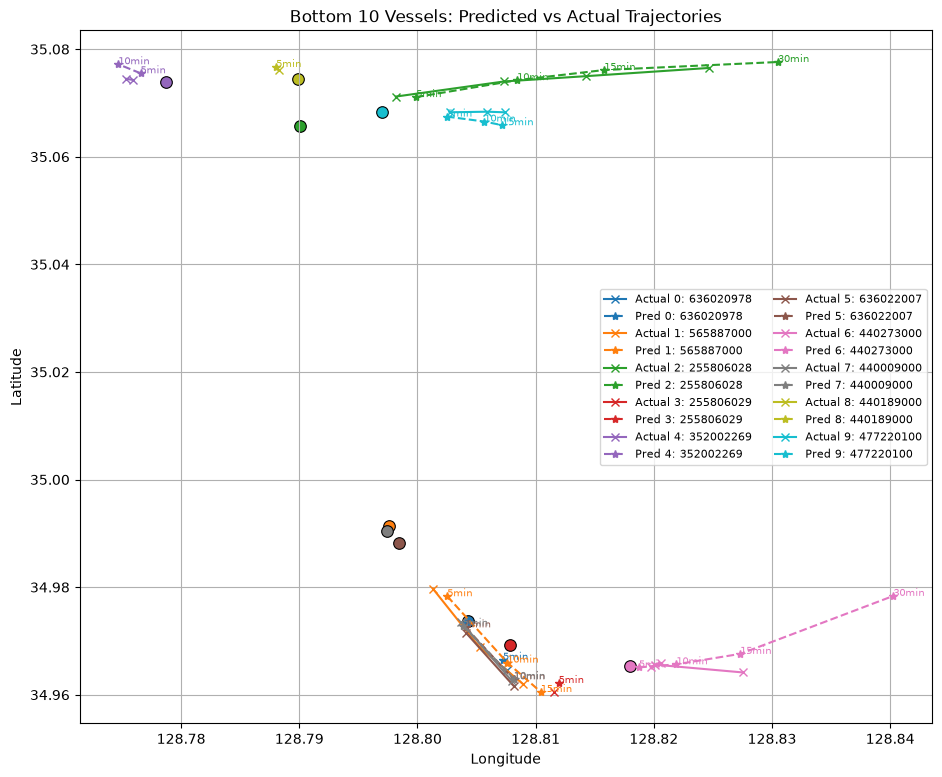

plotted vessels: 10


In [53]:
# 21. 상위/하위 10개 선박: 예측 움직임 vs 실제 움직임 그래프
# 노드: 5분, 10분, 15분, 30분, 1시간

def plot_pred_actual_paths(selected_paths, title):
    plt.figure(figsize=(11, 9))
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(selected_paths), 1)))
    plot_count = 0

    for i, item in enumerate(selected_paths):
        color = colors[i]
        merged = get_plot_nodes_5min(item, PLOT_HORIZONS)

        if merged is None:
            continue

        plot_count += 1

        plt.scatter(
            item["start_lon"], item["start_lat"],
            color=color, marker="o", s=70,
            edgecolor="black", linewidth=0.8
        )

        plt.plot(
            merged["lon_actual"], merged["lat_actual"],
            color=color, linestyle="-", marker="x", linewidth=1.5,
            label=f"Actual {i}: {item['MMSI']}"
        )

        plt.plot(
            merged["lon_pred"], merged["lat_pred"],
            color=color, linestyle="--", marker="*", linewidth=1.5,
            label=f"Pred {i}: {item['MMSI']}"
        )

        for _, row in merged.iterrows():
            plt.text(
                row["lon_pred"],
                row["lat_pred"],
                f"{int(row['forecast_minutes'])}min",
                fontsize=7,
                color=color
            )

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title)
    plt.grid(True)
    plt.legend(fontsize=8, ncol=2)

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style="plain", axis="both")

    plt.show()
    print("plotted vessels:", plot_count)


plot_pred_actual_paths(
    top10_paths,
    "Top 10 Vessels: Predicted vs Actual Trajectories"
)

plot_pred_actual_paths(
    bottom10_paths,
    "Bottom 10 Vessels: Predicted vs Actual Trajectories"
)

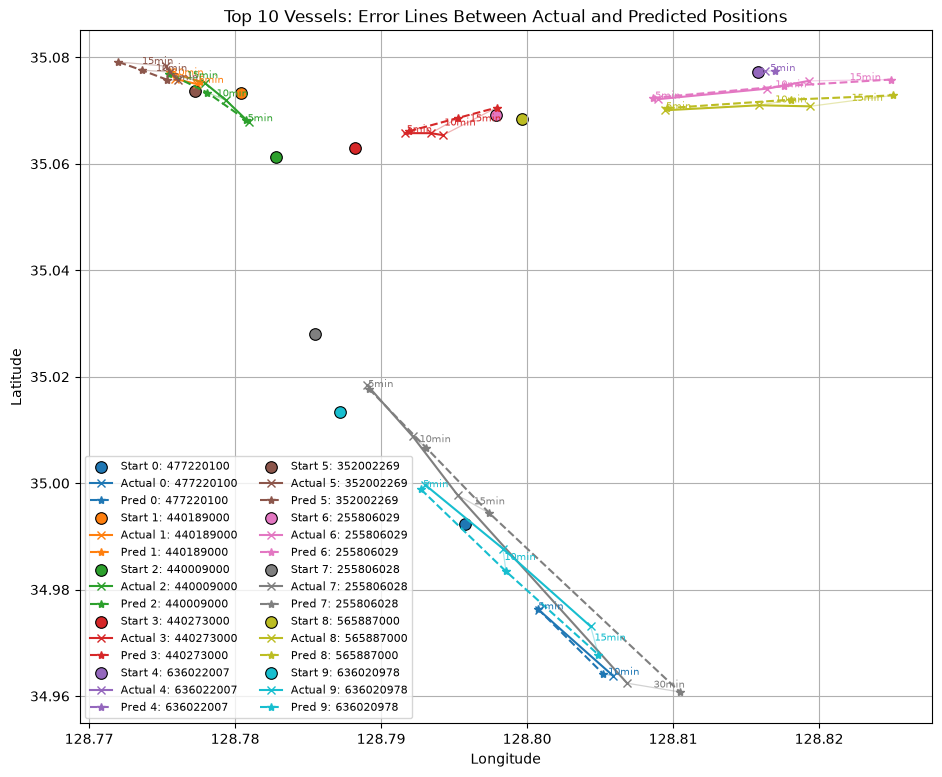

plotted vessels: 10


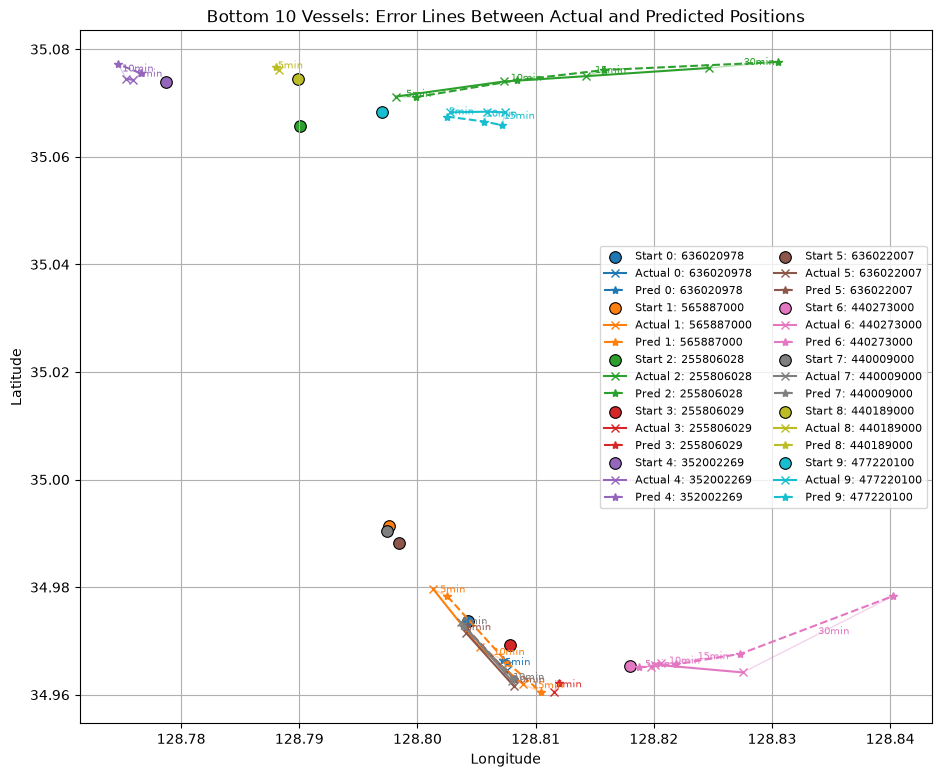

plotted vessels: 10


In [54]:
# 22. 상위/하위 10개 선박: 예측-실제 연결선 그래프
# 같은 horizon의 예측 위치와 실제 위치를 선으로 연결한다.

def plot_error_line_paths(selected_paths, title):
    plt.figure(figsize=(11, 9))
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(selected_paths), 1)))
    plot_count = 0

    for i, item in enumerate(selected_paths):
        color = colors[i]
        merged = get_plot_nodes_5min(item, PLOT_HORIZONS)

        if merged is None:
            continue

        plot_count += 1

        plt.scatter(
            item["start_lon"], item["start_lat"],
            color=color, marker="o", s=70,
            edgecolor="black", linewidth=0.8,
            label=f"Start {i}: {item['MMSI']}"
        )

        plt.plot(
            merged["lon_actual"], merged["lat_actual"],
            color=color, linestyle="-", marker="x", linewidth=1.5,
            label=f"Actual {i}: {item['MMSI']}"
        )

        plt.plot(
            merged["lon_pred"], merged["lat_pred"],
            color=color, linestyle="--", marker="*", linewidth=1.5,
            label=f"Pred {i}: {item['MMSI']}"
        )

        for _, row in merged.iterrows():
            plt.plot(
                [row["lon_actual"], row["lon_pred"]],
                [row["lat_actual"], row["lat_pred"]],
                color=color,
                alpha=0.35,
                linewidth=0.9
            )

            mid_lon = (row["lon_actual"] + row["lon_pred"]) / 2
            mid_lat = (row["lat_actual"] + row["lat_pred"]) / 2

            plt.text(
                mid_lon,
                mid_lat,
                f"{int(row['forecast_minutes'])}min",
                fontsize=7,
                color=color
            )

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title)
    plt.grid(True)
    plt.legend(fontsize=8, ncol=2)

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style="plain", axis="both")

    plt.show()
    print("plotted vessels:", plot_count)


plot_error_line_paths(
    top10_paths,
    "Top 10 Vessels: Error Lines Between Actual and Predicted Positions"
)

plot_error_line_paths(
    bottom10_paths,
    "Bottom 10 Vessels: Error Lines Between Actual and Predicted Positions"
)

,forecast_minutes,valid_count,mean_error_km,median_error_km,rmse_km,p90_error_km,max_error_km,mean_error_nm,median_error_nm
0,5,110,0.092450,0.085239,0.106686,0.179341,0.239570,0.049919,0.046026
1,10,89,0.212816,0.183613,0.254792,0.407297,0.726597,0.114911,0.099143
2,15,64,0.395205,0.294767,0.492279,0.700845,1.660850,0.213393,0.159161
3,30,9,0.997287,0.378762,1.590834,2.400207,4.153170,0.538492,0.204515
4,60,1,3.568585,3.568585,3.568585,3.568585,3.568585,1.926882,1.926882


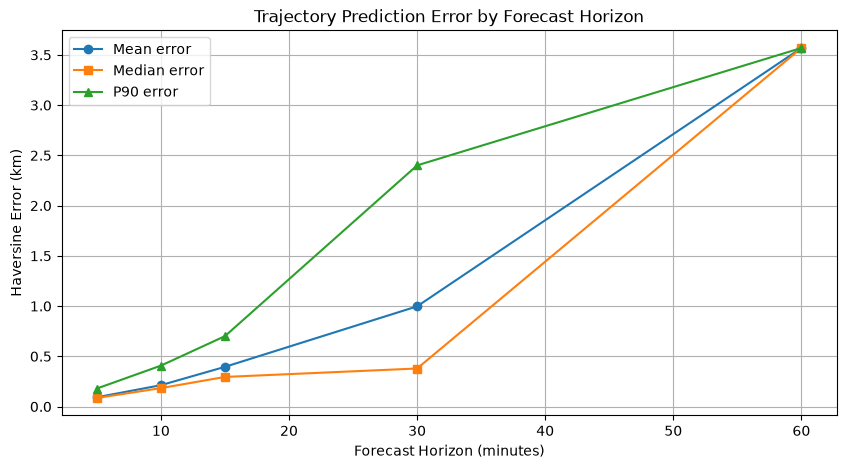

In [55]:
# 23. ?? ??: Horizon? ?? ?? ?? ??
# ?? ??? ??? ? ???? ????.

if len(trajectory_results_df) == 0:
    raise ValueError("trajectory_results_df? ?? ????. 19? ?? ?? ?? ?? ?????.")

trajectory_summary_df = (
    trajectory_results_df
    .groupby("forecast_minutes")
    .agg(
        valid_count=("error_km", "count"),
        mean_error_km=("error_km", "mean"),
        median_error_km=("error_km", "median"),
        rmse_km=("error_km", lambda x: np.sqrt(np.mean(np.square(x)))),
        p90_error_km=("error_km", lambda x: np.percentile(x, 90)),
        max_error_km=("error_km", "max"),
        mean_error_nm=("error_nm", "mean"),
        median_error_nm=("error_nm", "median")
    )
    .reset_index()
)

display(trajectory_summary_df)

plt.figure(figsize=(10, 5))
plt.plot(
    trajectory_summary_df["forecast_minutes"],
    trajectory_summary_df["mean_error_km"],
    marker="o",
    label="Mean error"
)
plt.plot(
    trajectory_summary_df["forecast_minutes"],
    trajectory_summary_df["median_error_km"],
    marker="s",
    label="Median error"
)
plt.plot(
    trajectory_summary_df["forecast_minutes"],
    trajectory_summary_df["p90_error_km"],
    marker="^",
    label="P90 error"
)

plt.xlabel("Forecast Horizon (minutes)")
plt.ylabel("Haversine Error (km)")
plt.title("Trajectory Prediction Error by Forecast Horizon")
plt.grid(True)
plt.legend()
plt.show()

In [56]:
# Folium 지도 시각화: 실제 궤적 vs 예측 궤적 + 예측 오차 연결선

import folium
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

trajectory_results_df = pd.DataFrame(trajectory_records)

BUSAN_PORT_CENTER = [35.104, 129.075]


def error_color(error_m):
    if error_m <= 50:
        return "#16a34a"   # green
    if error_m <= 100:
        return "#f97316"   # orange
    return "#dc2626"       # red


def popup_html(row):
    return "<br>".join([
        f"<b>MMSI</b>: {int(row['mmsi'])}",
        f"<b>Sample</b>: {int(row['sample_index'])}",
        f"<b>Step</b>: {int(row['step'])}",
        f"<b>Forecast</b>: {int(row['forecast_minutes'])} min",
        f"<b>Base Time</b>: {row['base_time']}",
        f"<b>True</b>: ({row['true_lat']:.6f}, {row['true_lon']:.6f})",
        f"<b>Pred</b>: ({row['pred_lat']:.6f}, {row['pred_lon']:.6f})",
        f"<b>Error</b>: {row['error_m']:.2f} m",
    ])


def add_label(row, layer):
    color = error_color(float(row["error_m"]))
    label = f"{int(row['forecast_minutes'])}min: {float(row['error_m']):.1f}m"

    html = (
        f'<div style="font-size:11px;font-weight:700;color:{color};'
        'background:rgba(255,255,255,0.82);border:1px solid #d1d5db;'
        'border-radius:3px;padding:1px 3px;white-space:nowrap;">'
        f"{label}</div>"
    )

    folium.Marker(
        location=[float(row["pred_lat"]), float(row["pred_lon"])],
        icon=folium.DivIcon(html=html),
    ).add_to(layer)


def build_map_dataframe(trajectory_results_df, trajectory_paths):
    result_df = trajectory_results_df.copy()

    result_df = result_df.rename(columns={
        "MMSI": "mmsi",
        "actual_lat": "true_lat",
        "actual_lon": "true_lon"
    })

    start_rows = []

    for sample_index, item in enumerate(trajectory_paths):
        start_rows.append({
            "sample_index": sample_index,
            "mmsi": item["MMSI"],
            "base_time": item["base_time"],
            "last_lat": item["start_lat"],
            "last_lon": item["start_lon"]
        })

    start_df = pd.DataFrame(start_rows)

    result_df = result_df.merge(
        start_df,
        on=["mmsi", "base_time"],
        how="inner"
    )

    result_df["step"] = (result_df["forecast_minutes"] // 5).astype(int)
    result_df["error_m"] = result_df["error_km"] * 1000

    result_df = result_df[
        [
            "sample_index",
            "mmsi",
            "base_time",
            "step",
            "forecast_minutes",
            "last_lat",
            "last_lon",
            "true_lat",
            "true_lon",
            "pred_lat",
            "pred_lon",
            "error_m"
        ]
    ].dropna()

    return result_df


def visualize_trajectory_map(
    trajectory_results_df,
    trajectory_paths,
    output_path="trajectory_prediction_map.html",
    max_samples=30,
    max_steps=20,
    center_lat=BUSAN_PORT_CENTER[0],
    center_lon=BUSAN_PORT_CENTER[1],
    zoom=12
):
    data = build_map_dataframe(trajectory_results_df, trajectory_paths)

    data["sample_index"] = data["sample_index"].astype(int)
    data["step"] = data["step"].astype(int)

    selected_samples = data["sample_index"].drop_duplicates().head(max_samples)
    data = data[
        data["sample_index"].isin(selected_samples)
        & data["step"].le(max_steps)
    ].copy()

    busan_map = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=zoom,
        tiles="OpenStreetMap"
    )

    start_layer = folium.FeatureGroup(name="Last observed positions", show=True)
    true_layer = folium.FeatureGroup(name="Actual future trajectories", show=True)
    pred_layer = folium.FeatureGroup(name="Predicted future trajectories", show=True)
    error_layer = folium.FeatureGroup(name="Prediction error lines", show=True)
    label_layer = folium.FeatureGroup(name="Error labels", show=True)

    for sample_index, group in data.groupby("sample_index", sort=False):
        group = group.sort_values("step")
        mmsi = int(group.iloc[0]["mmsi"])

        true_locations = group[["true_lat", "true_lon"]].to_numpy(dtype=float).tolist()
        pred_locations = group[["pred_lat", "pred_lon"]].to_numpy(dtype=float).tolist()

        folium.CircleMarker(
            location=[float(group.iloc[0]["last_lat"]), float(group.iloc[0]["last_lon"])],
            radius=5,
            color="#0f172a",
            fill=True,
            fill_opacity=0.9,
            tooltip=f"MMSI {mmsi} sample {sample_index} last observed",
        ).add_to(start_layer)

        if len(true_locations) >= 2:
            folium.PolyLine(
                true_locations,
                color="#2563eb",
                weight=3,
                opacity=0.75,
                tooltip=f"MMSI {mmsi} actual"
            ).add_to(true_layer)

        if len(pred_locations) >= 2:
            folium.PolyLine(
                pred_locations,
                color="#dc2626",
                weight=3,
                opacity=0.8,
                tooltip=f"MMSI {mmsi} predicted"
            ).add_to(pred_layer)

        for _, row in group.iterrows():
            true_point = [float(row["true_lat"]), float(row["true_lon"])]
            pred_point = [float(row["pred_lat"]), float(row["pred_lon"])]
            color = error_color(float(row["error_m"]))

            folium.CircleMarker(
                location=pred_point,
                radius=4,
                color=color,
                fill=True,
                fill_opacity=0.9,
                popup=folium.Popup(popup_html(row), max_width=360),
                tooltip=f"{int(row['forecast_minutes'])}min: {float(row['error_m']):.1f}m",
            ).add_to(pred_layer)

            folium.PolyLine(
                [true_point, pred_point],
                color=color,
                weight=1.5,
                opacity=0.65
            ).add_to(error_layer)

            add_label(row, label_layer)

    for layer in [start_layer, true_layer, pred_layer, error_layer, label_layer]:
        layer.add_to(busan_map)

    folium.LayerControl().add_to(busan_map)

    output_path = Path(output_path)
    busan_map.save(output_path)

    print(f"Saved map: {output_path.resolve()}")
    display(busan_map)

    return busan_map


trajectory_map = visualize_trajectory_map(
    trajectory_results_df,
    trajectory_paths,
    output_path="trajectory_prediction_map.html",
    max_samples=30,
    max_steps=20,
    zoom=12
)

Saved map: C:\Users\HP\Downloads\trajectory_prediction_map.html
